#Background
The real estate market is one of the most important sectors in many economies, and housing prices can vary significantly depending on several factors. Things such as the size of the property, the number of bedrooms and bathrooms, available amenities, and the overall location all influence the final price of a house. As cities continue to grow and housing demand increases, understanding how these differen

#Problem Statement
 The goal of this project is to develop a regression model that can predict the selling price of residential houses based on their physical characteristics and available amenities.

#Dataset Description
The dataset used in this project is obtained from the Kaggle Housing Prices Dataset created by Yasser H (ref). It contains information about residential properties along with their corresponding selling prices.

The dataset includes 545 observations and 13 input features, along with the target variable price, which represents the selling price of the property.  
- Price
- Area
- Bedrooms
- Bathrooms
- Stories
- Mainroad
- Guestroom
- Basement
- Hotwaterheating
- Airconditoning
- Parking
- Prefarea
- Furnishingstatus



#Step1: Import the main libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

#Step2: Load the dataset

In [3]:
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


#Step3: Review Data

In [4]:
df.shape


(545, 13)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


#Step4: Identify the target variable


In [7]:
target = "price"
print("Target column: ", target)

Target column:  price


#Step5: Check duplicates and missing values

In [8]:
df.duplicated().sum()
#check missing values

np.int64(0)

#Step6: Check distributions

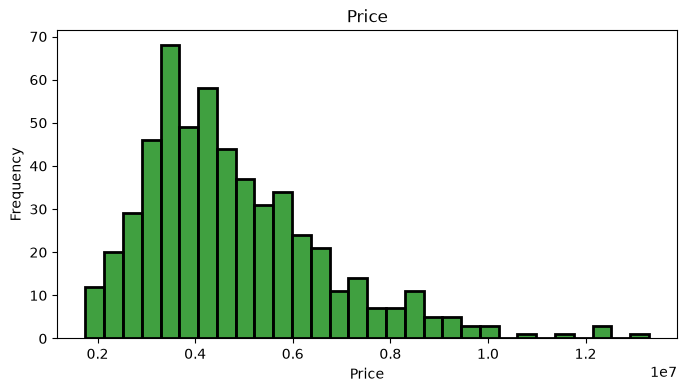

In [9]:
plt.figure(figsize=(8,4))
sns.histplot(
    df['price'],
    color='g',
    bins=30,
    edgecolor="black",
    linewidth=2
)
plt.title('Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

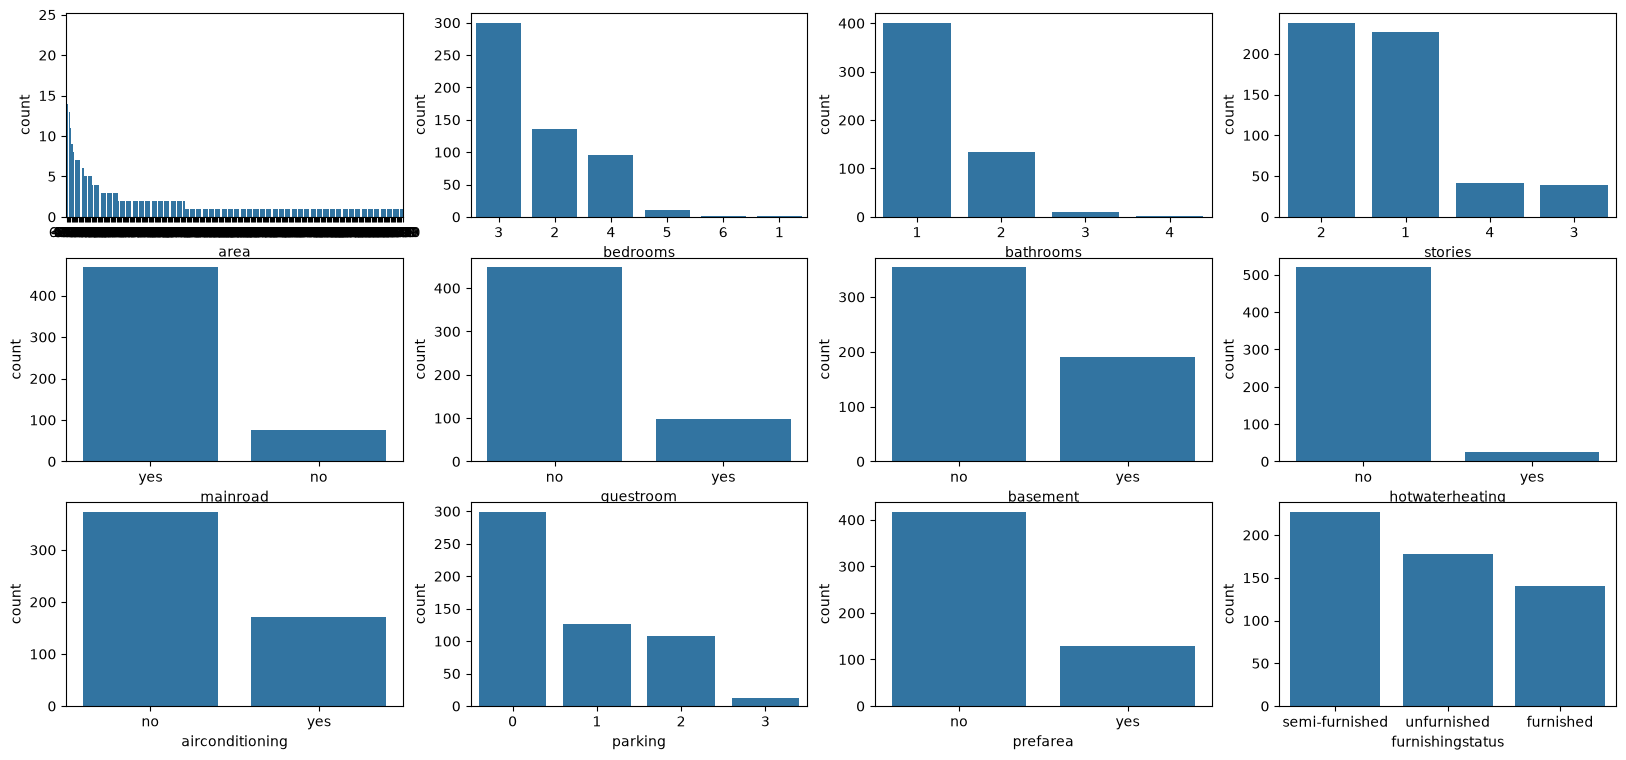

In [10]:
# print('\033[1mVisualising Categorical Features:'.center(100))
dffeature = df.drop('price', axis = 1)
feature = len(dffeature.columns)
n=4
r = 1
plt.figure(figsize=[20,3*math.ceil(feature/n)])

for i in range(feature):
    df.columns[i]
    plt.subplot( math.ceil(feature/n) , n , i + 1)
    sns.countplot(x= dffeature.columns[i], data=dffeature, order=dffeature[ dffeature.columns[i]].value_counts().index)



#Step7: Data Preprocessing



##Removing outliers



In [11]:
df = df[df['price'] <= 9700000]   # Prices above 9700000 are underrepresetned
df = df[df['area'] <= 13000]  # Area below 13000 are underrepresetned
df = df[df['bedrooms'] != 6] # Only 2 samples with 6 bedrooms
df = df[df['bedrooms'] != 1] # Only 2 samples with 1 bedroom

#Convert binary columns to 0 and 1


In [12]:
df['mainroad'] = df['mainroad'].map(({'yes': 1, 'no': 0}))
df['guestroom'] = df['guestroom'].map(({'yes': 1, 'no': 0}))
df['basement'] = df['basement'].map(({'yes': 1, 'no': 0}))
df['airconditioning'] = df['airconditioning'].map(({'yes': 1, 'no': 0}))
df['hotwaterheating'] = df['hotwaterheating'].map(({'yes': 1, 'no': 0}))
df['prefarea'] = df['prefarea'].map(({'yes': 1, 'no': 0}))
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
11,9681000,6000,4,3,2,1,1,1,1,0,2,0,semi-furnished
12,9310000,6550,4,2,2,1,0,0,0,1,1,1,semi-furnished
13,9240000,3500,4,2,2,1,0,0,1,0,2,0,furnished
14,9240000,7800,3,2,2,1,0,0,0,0,0,1,semi-furnished
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,semi-furnished


#Apply one-hot encoding to 'furnishingstatus' column

In [13]:
df['furnishingstatus'].unique()
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True, dtype = int)


In [14]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
11,9681000,6000,4,3,2,1,1,1,1,0,2,0,1,0
12,9310000,6550,4,2,2,1,0,0,0,1,1,1,1,0
13,9240000,3500,4,2,2,1,0,0,1,0,2,0,0,0
14,9240000,7800,3,2,2,1,0,0,0,0,0,1,1,0
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,1,0


#Step8: Check Feature Co-relation

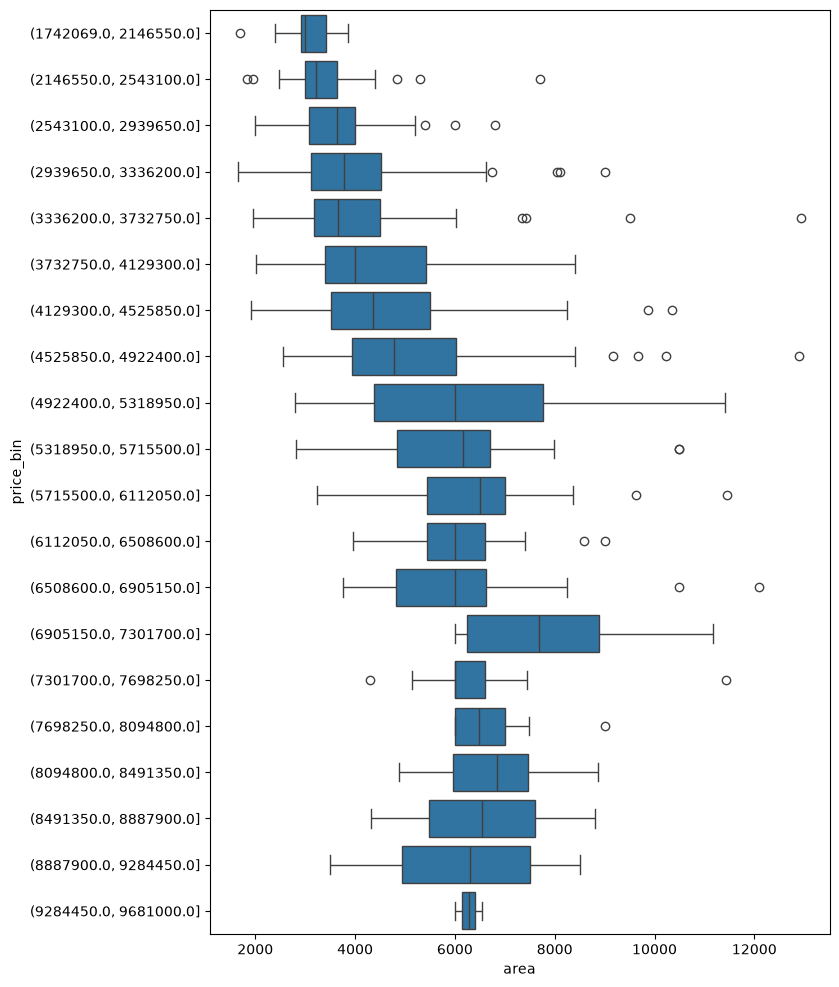

In [15]:
df['price_bin'] = pd.cut(df['price'], bins=20)

plt.figure(figsize=(8,12))
sns.boxplot(x='area',y='price_bin',data=df,orient='h')

df = df.drop('price_bin', axis=1)

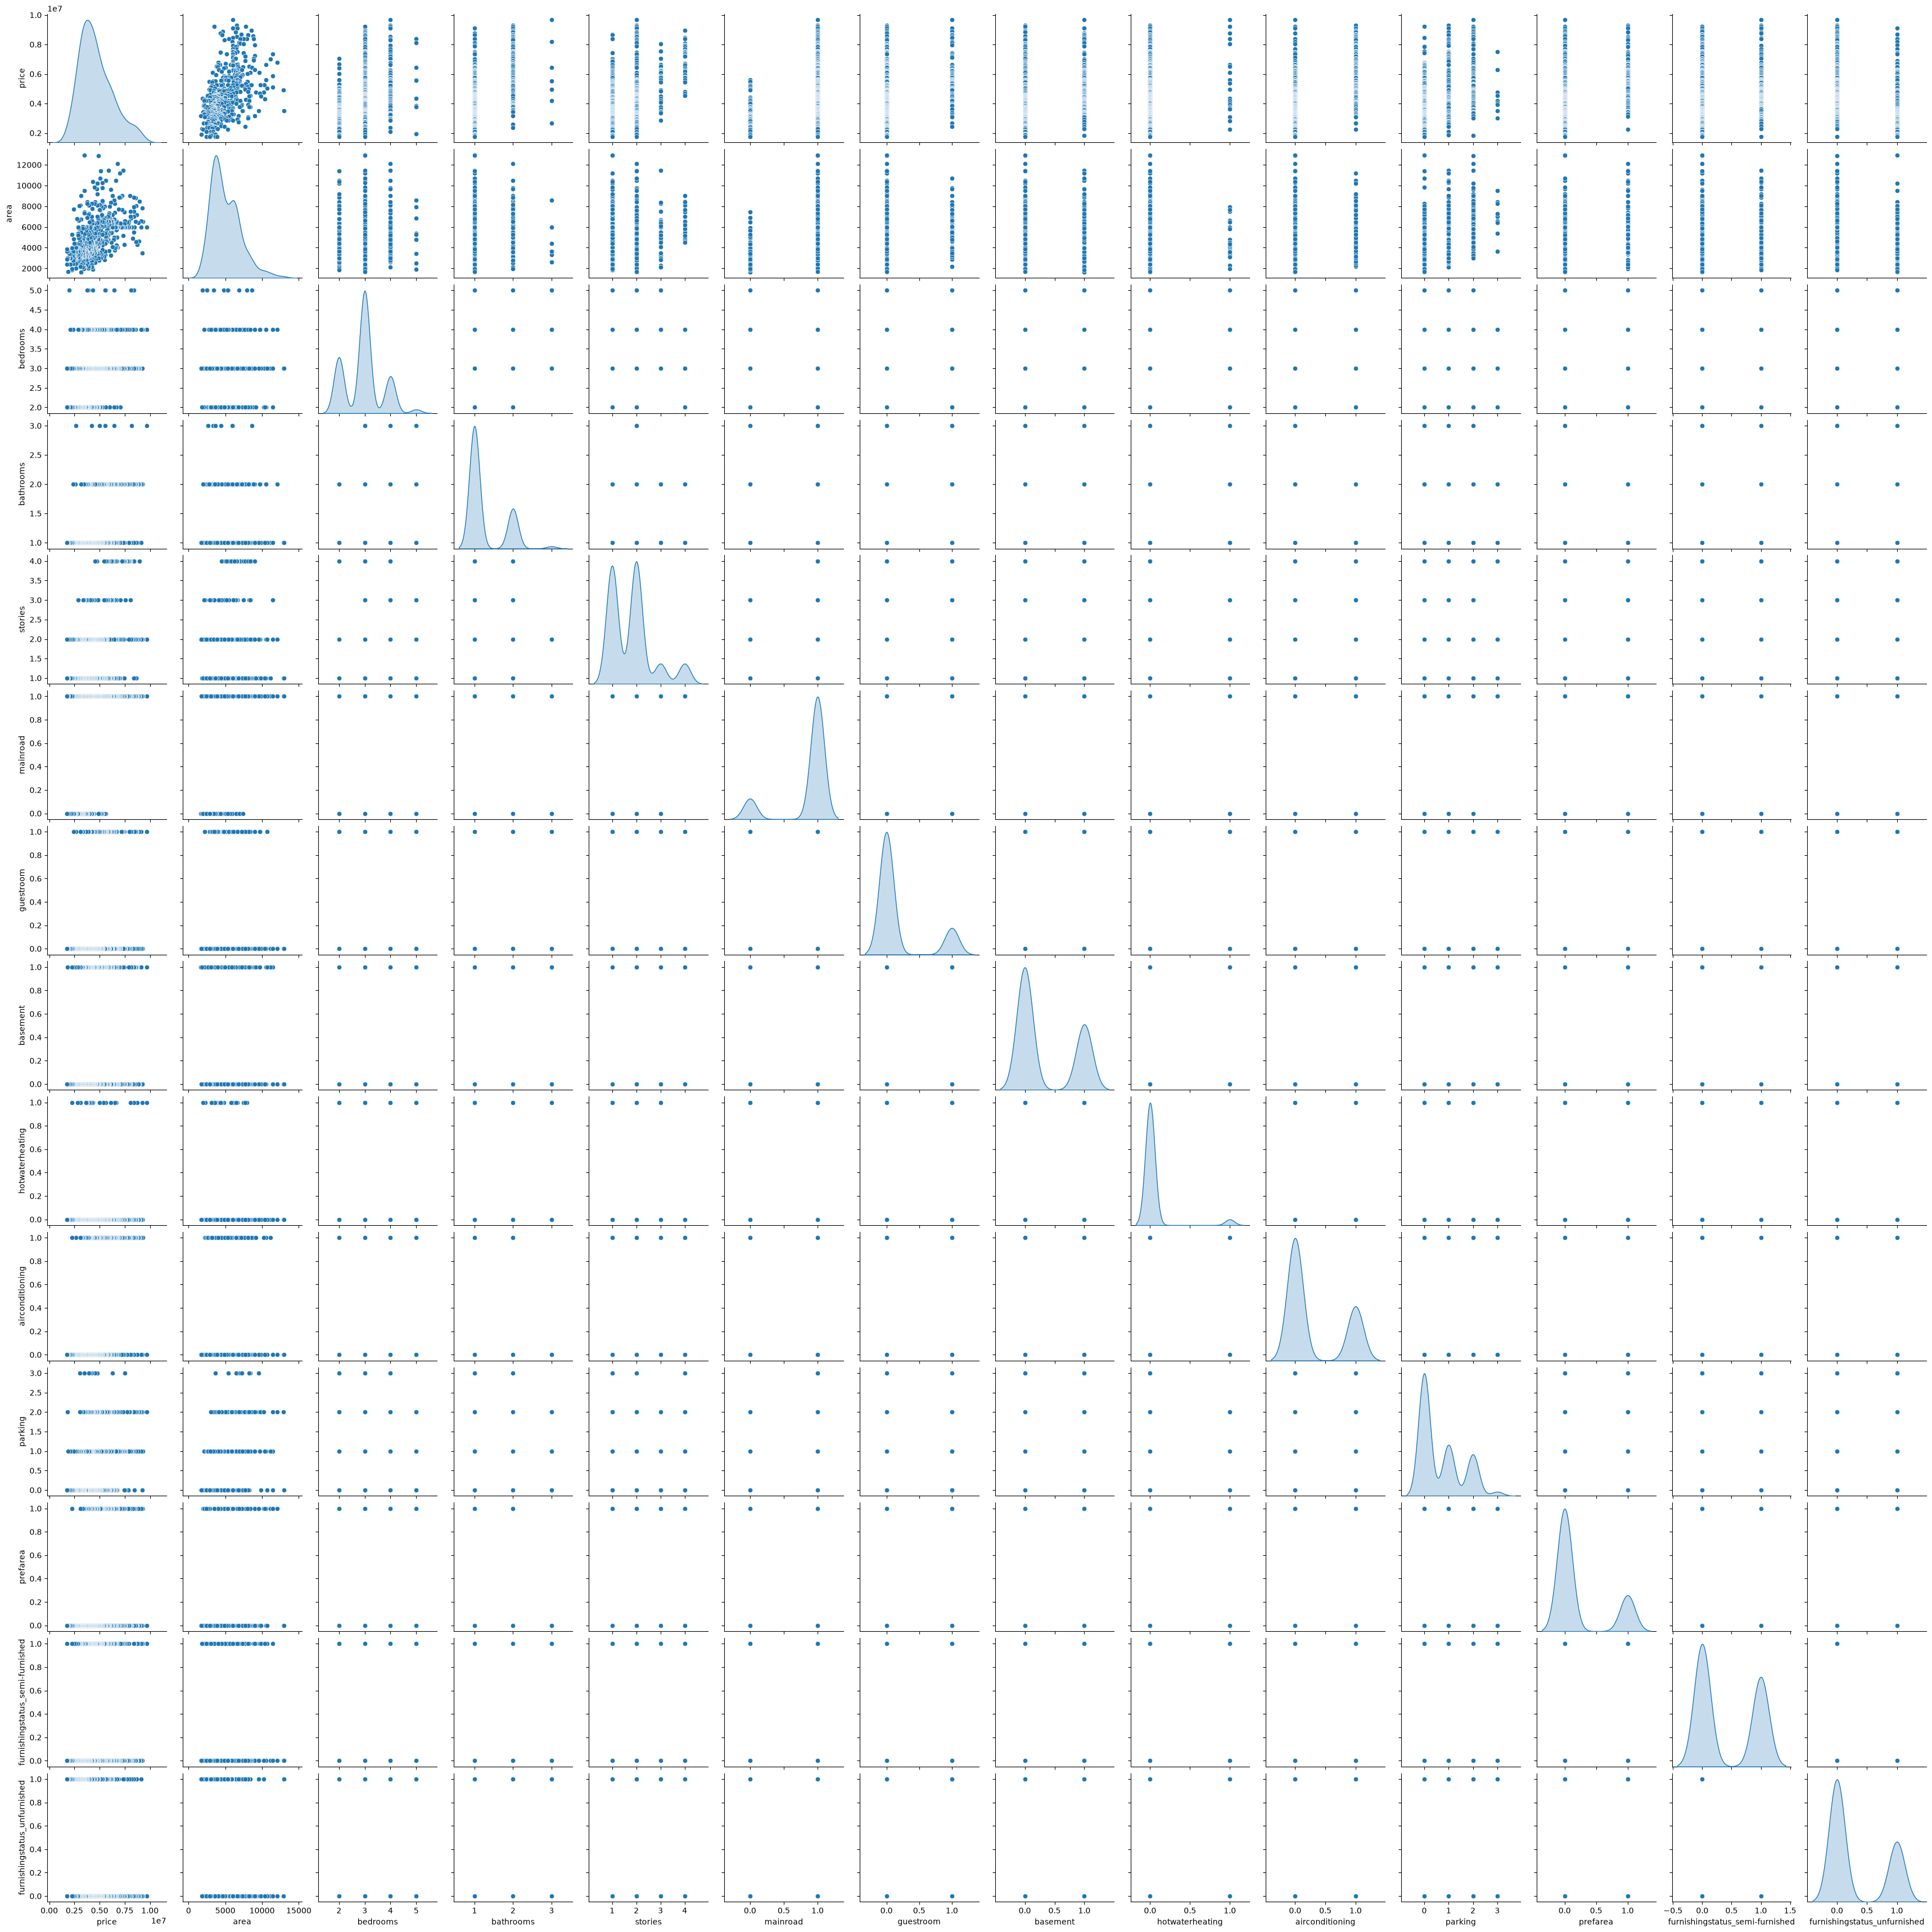

In [16]:
sns.pairplot(df, diag_kind='kde')


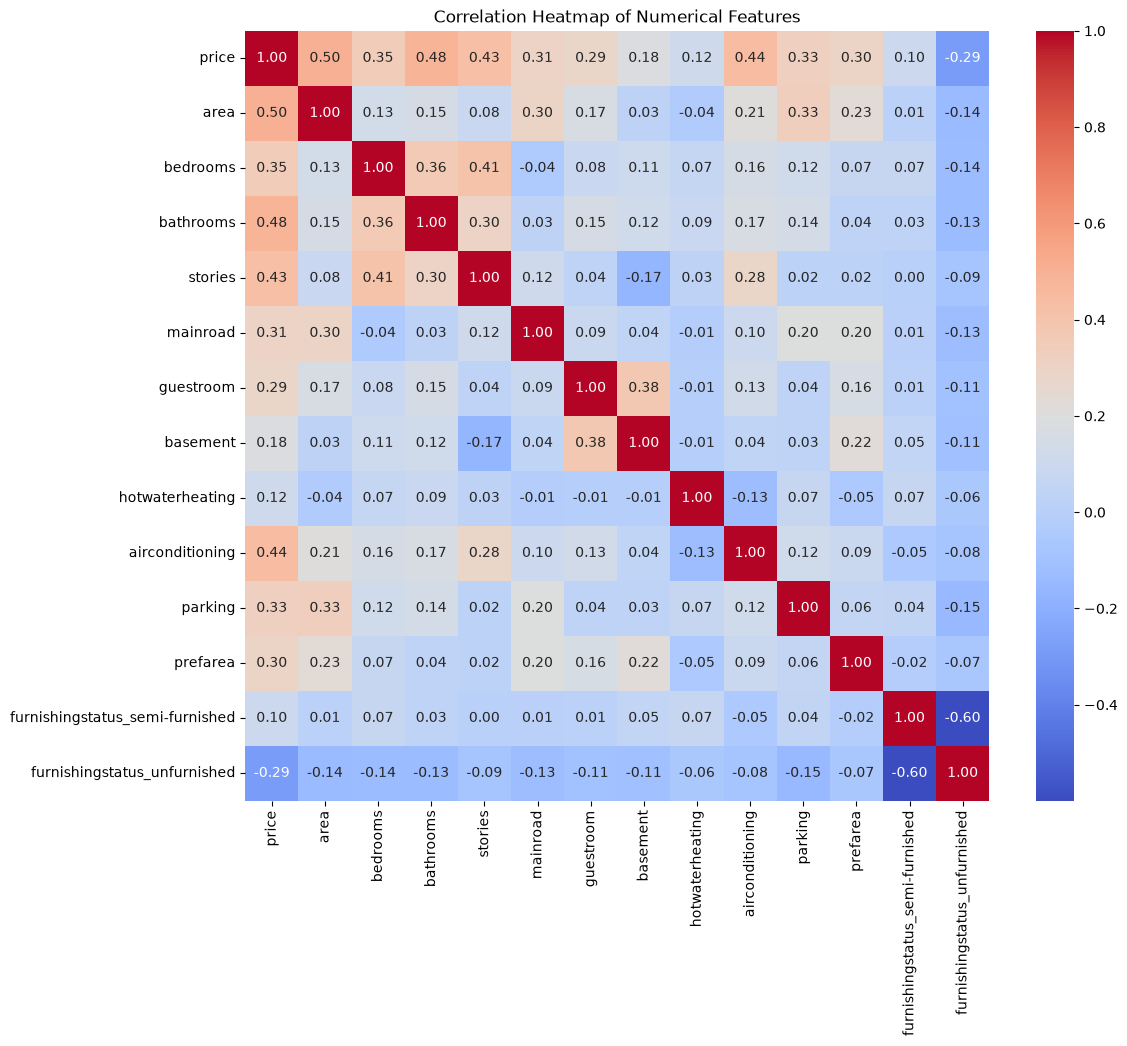

In [17]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

#Step9: Data Spliting for training

In [21]:
from sklearn.model_selection import train_test_split, cross_validate

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")



X_train shape: (422, 13)
X_test shape: (106, 13)
y_train shape: (422,)
y_test shape: (106,)


#Step10: Scale Data

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

columns_to_scale = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'parking'
]


scaler.fit(X_train[columns_to_scale])
X_train[columns_to_scale] = scaler.transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

#Step11: Train Linear Regression model

Starting with Linear regression  as a baseline model and evaluate its performance.

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate


model = LinearRegression()
model.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 460348. , 51078.14, 382587.67,..., 589104.35, 42618.87,-335822.1 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['area','bedrooms','bathrooms',...,'prefarea', 'furnishingstatus_semi-furnished','furnishingstatus_unfurnished']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.709e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


#Model Evaluate

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2: {r2:.2f}")

Mean Absolute Error (MAE): 899142.36
Root Mean Squared Error (RMSE): 1173782.58
R2: 0.60


In [25]:
print("Training Error Metrics")
train_pred = model.predict(X_train)
train_mae = mean_absolute_error(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, train_pred)
print(f"MAE: {train_mae:.2f}")
print(f"RMSE: {train_rmse:.2f}")
print(f"R2: {train_r2:.2f}")

Training Error Metrics
MAE: 667541.62
RMSE: 905691.80
R2: 0.67


In [26]:
model.coef_

array([ 460348.00345082,   51078.13537317,  382587.67272821,
        362624.87262895,  450729.23557283,  329208.98964146,
        278866.1762144 ,  322738.89138309,  873375.1897322 ,
        133855.96957187,  589104.35254838,   42618.86945644,
       -335822.10177298])

In [27]:
model.intercept_

np.float64(3709206.6899001524)

In [28]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})
feature_importance

,Feature,Coefficient
0,area,460348.003451
1,bedrooms,51078.135373
2,bathrooms,382587.672728
3,stories,362624.872629
4,mainroad,450729.235573
5,guestroom,329208.989641
6,basement,278866.176214
7,hotwaterheating,322738.891383
8,airconditioning,873375.189732
9,parking,133855.969572


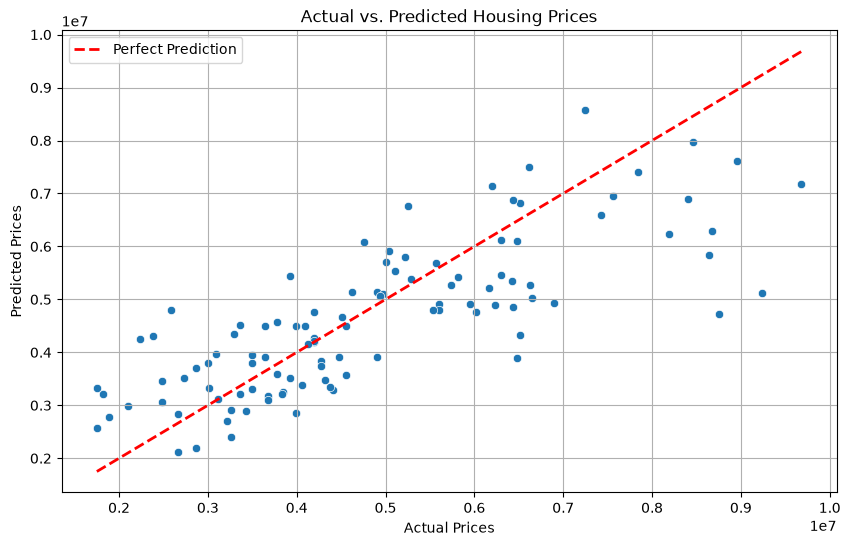

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted Housing Prices')

# Plot a diagonal line for perfect prediction
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.legend()
plt.grid(True)
plt.show()

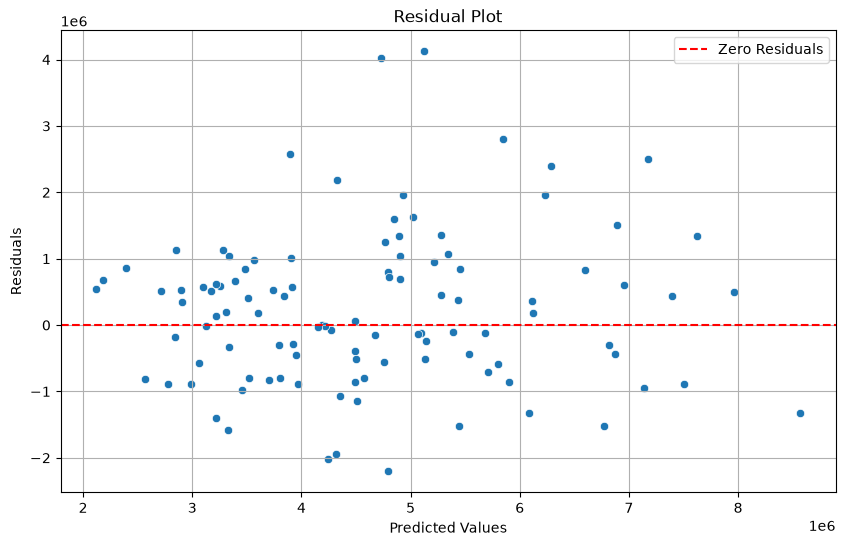

In [30]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residuals')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.legend()
plt.grid(True)
plt.show()

# Train Polynomial Regression (Deg 2, 3, 4)


In [31]:
from sklearn.preprocessing import PolynomialFeatures


# Assume X_train, X_test, y_train, y_test already defined
rmse_train_arr = []
mae_train_arr = []
rmse_test_arr = []
mae_test_arr = []

for degree in [2, 3, 4]:
    # Generate polynomial features
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Fit linear regression
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predict
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Metrics for training set
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    rmse_train_arr.append(rmse_train)
    mae_train_arr.append(mae_train)

    # Metrics for test set
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    rmse_test_arr.append(rmse_test)
    mae_test_arr.append(mae_test)


    print(f"Degree {degree}:")
    print(f"  Train ->  RMSE = {rmse_train:.2f}, MAE = {mae_train:.2f}, R2 = {r2_train:.4f}")
    print(f"  Test  ->  RMSE = {rmse_test:.2f}, MAE = {mae_test:.2f}, R2 = {r2_test:.4f}\n")

Degree 2:
  Train ->  RMSE = 738280.80, MAE = 538748.05, R2 = 0.7802
  Test  ->  RMSE = 1255758.32, MAE = 928837.74, R2 = 0.5449

Degree 3:
  Train ->  RMSE = 278757.98, MAE = 163868.76, R2 = 0.9687
  Test  ->  RMSE = 18652440.87, MAE = 9532348.42, R2 = -99.4003

Degree 4:
  Train ->  RMSE = 100229.90, MAE = 23316.95, R2 = 0.9959
  Test  ->  RMSE = 102009617.19, MAE = 37311947.65, R2 = -3001.9353



In [32]:
 #Temmp
 degrees = [2, 3, 4]

plt.figure(figsize=(12,5))

# ---- RMSE subplot ----
plt.subplot(1, 2, 1)
plt.plot(degrees, rmse_train_arr, marker='o', label='Train RMSE')
plt.plot(degrees, rmse_test_arr, marker='o', label='Test RMSE')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('Train vs Test RMSE')
plt.xticks(degrees)
plt.legend()
plt.grid(True)

# ---- MAE subplot ----
plt.subplot(1, 2, 2)
plt.plot(degrees, mae_train_arr, marker='x', label='Train MAE')
plt.plot(degrees, mae_test_arr, marker='x', label='Test MAE')
plt.xlabel('Polynomial Degree')
plt.ylabel('MAE')
plt.title('Train vs Test MAE')
plt.xticks(degrees)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

IndentationError: unexpected indent (1259784175.py, line 2)

#Train and Evaluate Regularized Polynomial Regression (Degree 2)

In [35]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

elastic_model = ElasticNetCV(l1_ratio=[.1, .5, .7,.9, .95, .99, 1],
                             alphas=np.logspace(-4, 2, 50),
                             cv=5,
                             max_iter=1000)
elastic_model.fit(X_train_poly,y_train)

/opt/anaconda3/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.116e+10, tolerance: 7.392e+10
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.930e+13, tolerance: 7.392e+10
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/ml/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisat

,l1_ratio,"[0.1, 0.5, ...]"
,eps,0.001
,n_alphas,'deprecated'
,alphas,array([1.0000...00000000e+02])
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,cv,5
,copy_X,True
,verbose,0


In [36]:
# Best alpha (regularization strength)
best_alpha = elastic_model.alpha_

# Best L1 ratio (lambda in some contexts)
best_l1_ratio = elastic_model.l1_ratio_
print(f"Best L1 ratio: {best_l1_ratio}, Best alpha: {best_alpha}")


Best L1 ratio: 0.95, Best alpha: 2.559547922699533


#Evaluate model

In [37]:
y_pred = elastic_model.predict(X_test_poly)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2: {r2:.2f}")


Mean Absolute Error (MAE): 871434.68
Root Mean Squared Error (RMSE): 1183977.76
R2: 0.60


In [38]:
print("Training Error Metrics")
train_pred = elastic_model.predict(X_train_poly)
train_mae = mean_absolute_error(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, train_pred)
print(f"MAE: {train_mae:.2f}")
print(f"RMSE: {train_rmse:.2f}")
print(f"R2: {train_r2:.2f}")

Training Error Metrics
MAE: 593866.47
RMSE: 802202.94
R2: 0.74


#Train and Evaluate Random Forest

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

#Sice scaling is not required
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


n_estimators=[64,100,128,200]
max_features= [3,4,5]
bootstrap = [True]
max_depth= [5, 10, 20]
min_samples_leaf= [1, 2, 5, 10]


param_grid = {'n_estimators':n_estimators,
             'max_features':max_features,
            #  'bootstrap':bootstrap,
              'max_depth': max_depth,
              'min_samples_leaf': [1, 2, 5, 10]}


model = RandomForestRegressor()
grid = GridSearchCV(model,param_grid, cv=5,scoring='r2')
grid.fit(X_train,y_train)


,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [5, 10, ...], 'max_features': [3, 4, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [64, 100, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [40]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": grid.best_estimator_.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

                            Feature  Importance
0                              area    0.306276
2                         bathrooms    0.136224
8                   airconditioning    0.114208
3                           stories    0.089841
9                           parking    0.069107
1                          bedrooms    0.065519
10                         prefarea    0.049169
12     furnishingstatus_unfurnished    0.043801
6                          basement    0.039389
5                         guestroom    0.028586
4                          mainroad    0.028096
11  furnishingstatus_semi-furnished    0.021676
7                   hotwaterheating    0.008108


In [41]:
grid.best_params_

{'max_depth': 10,
 'max_features': 3,
 'min_samples_leaf': 1,
 'n_estimators': 200}

#Evaluate model

In [42]:
y_pred = grid.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R2: {r2:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 883859.30
R2: 0.56
Root Mean Squared Error (RMSE): 1229281.88


In [43]:
print("Training Error Metrics")
train_pred = grid.predict(X_train)
train_mae = mean_absolute_error(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, train_pred)
print(f"MAE: {train_mae:.2f}")
print(f"RMSE: {train_rmse:.2f}")
print(f"R2: {train_r2:.2f}")

Training Error Metrics
MAE: 325755.45
RMSE: 439229.96
R2: 0.92
